/opt/exoplanet/venv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


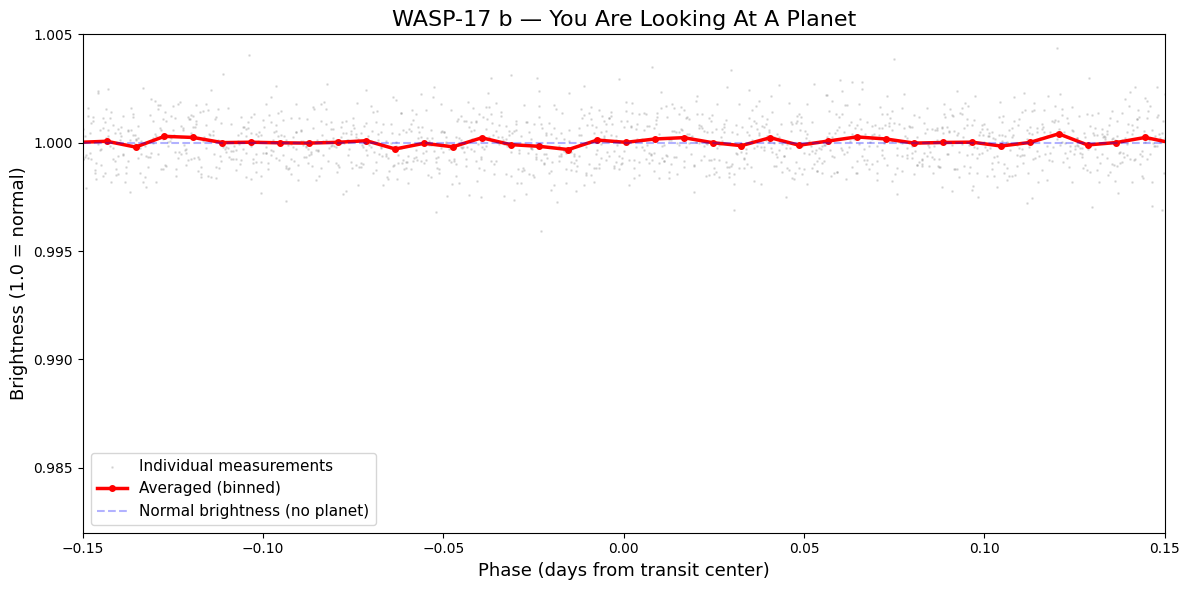


The red line dips to about 0.9995
Transit depth: 0.05% — the planet blocks 0.05% of starlight
Planet orbits every 3.74 days (89.6 hours)
This star is about 1,300 light years from Sydney.


In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Download WASP-17 b data (just one sector to keep it simple)
print("Downloading WASP-17 b from TESS Sector 14...")
lc = lk.search_lightcurve("TIC 103633434", mission="TESS", 
                            author="SPOC", sector=14).download()
lc_clean = lc.flatten(window_length=401).remove_outliers(sigma=4)

# Phase-fold at the known period
folded = lc_clean.fold(period=3.7354, epoch_time=1684.39)
binned = folded.bin(time_bin_size=0.008)

# Plot it
fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(folded.phase.value, folded.flux.value, s=1, alpha=0.2, 
           color='gray', label='Individual measurements')
ax.plot(binned.phase.value, binned.flux.value, 'o-', color='red', 
        markersize=4, linewidth=2.5, label='Averaged (binned)')
ax.axhline(y=1.0, color='blue', linestyle='--', alpha=0.3, 
           label='Normal brightness (no planet)')
ax.set_xlim(-0.15, 0.15)
ax.set_ylim(0.982, 1.005)
ax.set_xlabel('Phase (days from transit center)', fontsize=13)
ax.set_ylabel('Brightness (1.0 = normal)', fontsize=13)
ax.set_title('WASP-17 b — You Are Looking At A Planet', fontsize=16)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

depth = (1.0 - np.nanmin(binned.flux.value)) * 100
print(f"\nThe red line dips to about {1.0 - depth/100:.4f}")
print(f"Transit depth: {depth:.2f}% — the planet blocks {depth:.2f}% of starlight")
print(f"Planet orbits every 3.74 days (89.6 hours)")
print(f"This star is about 1,300 light years from Sydney.")

Running BLS — searching all periods from 0.5 to 15 days...
BLS found period: 3.4434 d
Known period:     3.7354 days
Match: NO


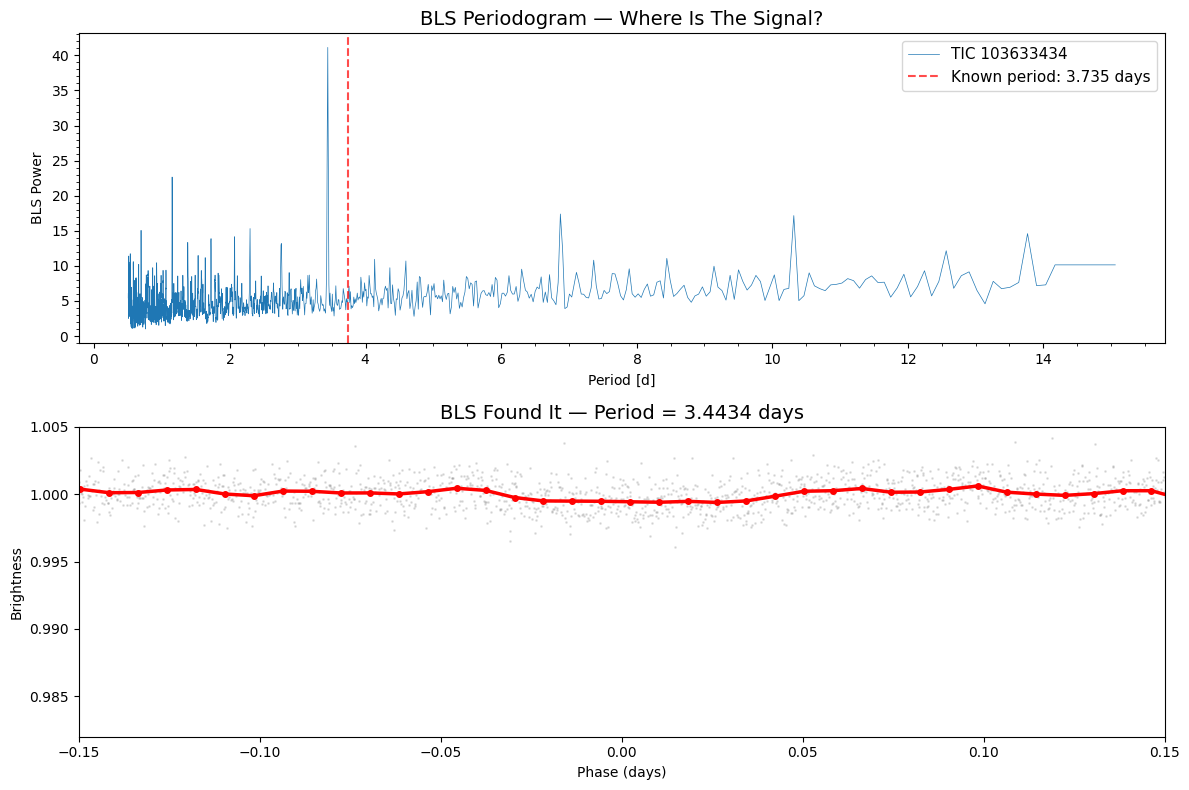


BLS searched thousands of possible periods and found the planet.
This is exactly what your pipeline does on stars with NO known planets.


In [2]:
# Now pretend we DON'T know the period. Let BLS find it.
# Using just one sector so BLS doesn't choke on the grid size.
print("Running BLS — searching all periods from 0.5 to 15 days...")
pg = lc_clean.to_periodogram(method='bls', 
                              minimum_period=0.5, 
                              maximum_period=15.0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Periodogram — spike = detected period
pg.plot(ax=ax1)
ax1.set_title('BLS Periodogram — Where Is The Signal?', fontsize=14)
ax1.axvline(3.7354, color='red', linestyle='--', alpha=0.7, 
            label=f'Known period: 3.735 days')
ax1.legend(fontsize=11)

# Phase-fold at whatever BLS found
best_p = pg.period_at_max_power
best_t0 = pg.transit_time_at_max_power
print(f"BLS found period: {best_p:.4f}")
print(f"Known period:     3.7354 days")
print(f"Match: {'YES' if abs(best_p.value - 3.7354) < 0.01 else 'NO'}")

bls_folded = lc_clean.fold(period=best_p, epoch_time=best_t0)
bls_binned = bls_folded.bin(time_bin_size=0.008)

ax2.scatter(bls_folded.phase.value, bls_folded.flux.value, 
            s=1, alpha=0.2, color='gray')
ax2.plot(bls_binned.phase.value, bls_binned.flux.value, 'o-', 
         color='red', markersize=4, linewidth=2.5)
ax2.set_xlim(-0.15, 0.15)
ax2.set_ylim(0.982, 1.005)
ax2.set_title(f'BLS Found It — Period = {best_p.value:.4f} days', fontsize=14)
ax2.set_xlabel('Phase (days)')
ax2.set_ylabel('Brightness')

plt.tight_layout()
plt.show()
print("\nBLS searched thousands of possible periods and found the planet.")
print("This is exactly what your pipeline does on stars with NO known planets.")